In [20]:
%run C:/Users/caleb/ML2Project/AMMCalc.ipynb

In [21]:
# %run C:/Users/caleb/ML2Project/AMMData2.ipynb

In [3]:
ENV_CONFIG = {"initialCash": 100000.0,    "maxInventory": 500,    "tickSize": 0.01,    "episodeLen": 1000,    "feePerShare": 0.001,    "seed": 123,
              "baseProb": 0.12,    "maxProb": 0.60,    "lamScale": 100.0,    "imbFillWeight": 1.2,    "intensityFillWeight": 1.0,    "tickDecay": 0.4,           
              "aggressiveBonus": 3.5,  "toxImb": 0.3,    "toxPxChg": 0.4,    "toxIntensity": 0.2,    "toxSpread": 0.1,    "spreadToxThreshold": 0.15,
              "fillFracMin": 0.25,    "fillFracMax": 0.75,    "idlePenalty": 1e-5}

AGENT_CONFIG = {"stateSize": 24,    "actionSize": 20,    "learningRate": 1e-3,    "gamma": 0.95,    "epsilonStart": 1.0,    "epsilonEnd": 0.05,
                "epsilonDecay": 0.994,    "batchSize": 256,    "targetUpdateFreq": 2000,    "bufferCapacity": 200_000,    "lstmLr": 3e-4,
                "lambdaMax": (0.5, 0.3, 1.0),    "defaultLambdas": (0.01, 0.05, 0.75),    "regimeWindow": 100,    "lambdaRefreshFreq": 50}

FEATURE_CONFIG = {"VolatilityWindow": (500,),    "downsampling": 100,    "hawkMu": 1.0,
                  "hawkAlpha": 0.5,    "hawkBeta": 2.0,    "historyMaxLen": 2000}

AS_CONFIG = {"gamma": 0.1,    "kappa": 1.5,    "episodeLen": 1000,    "feePerShare": 0.001}


In [4]:
# Create Environment
envTrain = AMMEnvironment(dfTrain, **ENV_CONFIG)
envVal   = AMMEnvironment(dfVal,   **ENV_CONFIG)
envTest  = AMMEnvironment(dfTest,  **ENV_CONFIG)

In [24]:
# Create Agent
agentDQN = MetaDQNAgent(**AGENT_CONFIG)
dqnTrainLog = []

for ep in range(2000):
    # Train, with no updating
    metrics, totalR = agentDQN.trainEpisode(envTrain, updateMeta=False)
    # Create metrics to print
    pnlPerTrade = metrics['finalPnl'] / max(metrics['totalTrades'], 1)
    dqnTrainLog.append({"ep": ep + 1,        "pnl": metrics['finalPnl'],        "pnlPerTrade": pnlPerTrade,        "sharpe": metrics['sharpeRatio'],
                        "trades": metrics['totalTrades'],        "totalRew": totalR,        "epsilon": agentDQN.epsilon})
    # Prints every 25 eps
    if (ep + 1) % 25 == 0:
        print(f"[DQN] Ep {ep+1}/2000 | PnL: {metrics['finalPnl']:.2f} | PnL/Trade: {pnlPerTrade:.3f} | Sharpe: {metrics['sharpeRatio']:.3f} | Trades: {metrics['totalTrades']} | TotalRew: {totalR:.2f} | BufSize: {len(agentDQN.replayBuffer)} | Eps: {agentDQN.epsilon:.3f}")


In [23]:
agentMeta = MetaDQNAgent(**AGENT_CONFIG)
metaTrainLog = []

# DQN training only
for ep in range(500):
    metrics, totalR = agentMeta.trainEpisode(envTrain, updateMeta=False)
    pnlPerTrade = metrics['finalPnl'] / max(metrics['totalTrades'], 1)
    lam = agentMeta.currentLambdas
    metaTrainLog.append({"ep": ep + 1,"phase": "warmup", "pnl": metrics['finalPnl'], "pnlPerTrade": pnlPerTrade, "sharpe": metrics['sharpeRatio'],
                         "trades": metrics['totalTrades'], "totalRew": totalR, "epsilon": agentMeta.epsilon, 
                         "lam0": float(lam[0]), "lam1": float(lam[1]), "lam2": float(lam[2])})
    if (ep + 1) % 25 == 0:
        print(f"[Meta warmup] Ep {ep+1}/300 | PnL: {metrics['finalPnl']:.2f} | PnL/Trade: {pnlPerTrade:.3f} | Sharpe: {metrics['sharpeRatio']:.3f} | Trades: {metrics['totalTrades']} | TotalRew: {totalR:.2f} | BufSize: {len(agentMeta.replayBuffer)} | Eps: {agentMeta.epsilon:.3f}")

# LSTM Training
for ep in range(1500):
    metrics, totalR = agentMeta.trainEpisode(envTrain, updateMeta=True)
    pnlPerTrade = metrics['finalPnl'] / max(metrics['totalTrades'], 1)
    lam = agentMeta.currentLambdas
    metaTrainLog.append({"ep": ep + 301, "phase": "active", "pnl": metrics['finalPnl'], "pnlPerTrade": pnlPerTrade, "sharpe": metrics['sharpeRatio'],
                         "trades": metrics['totalTrades'], "totalRew": totalR, "epsilon": agentMeta.epsilon,
                         "lam0": float(lam[0]), "lam1": float(lam[1]), "lam2": float(lam[2])})
    if (ep + 1) % 25 == 0:
        print(f"[Meta active] Ep {ep+1}/1700 | PnL: {metrics['finalPnl']:.2f} | PnL/Trade: {pnlPerTrade:.3f} | Trades: {metrics['totalTrades']} | TotalRew: {totalR:.2f} | BufSize: {len(agentMeta.replayBuffer)} | Eps: {agentMeta.epsilon:.3f} | Lambdas =({lam[0]:.4f}, {lam[1]:.4f}, {lam[2]:.4f})")

In [14]:
# Create AS Model
asModel = AvellanedaStoikov(**AS_CONFIG)

In [15]:
# Collect Eval outputs
def runEval(agent, env, n=50, isAS=False):
    results = []
    for _ in range(n):
        m, totalR = agent.evaluateEpisode(env)
        results.append({"pnl": m["finalPnl"], "sharpe": m["sharpeRatio"], "trades": m["totalTrades"], "finalInv": m["finalInventory"], "wealth": m["finalWealth"], "totalRew": totalR})
    return results


In [ ]:
# Run on all legs of data
dqnVal   = runEval(agentDQN,  envVal)
dqnTest  = runEval(agentDQN,  envTest)
metaVal  = runEval(agentMeta, envVal)
metaTest = runEval(agentMeta, envTest)
asVal    = runEval(asModel,   envVal)
asTest   = runEval(asModel,   envTest)

In [25]:
# Summary Info
def summarize(name, data):
    pnls    = [d["pnl"]      for d in data]
    sharpes = [d["sharpe"]   for d in data]
    trades  = [d["trades"]   for d in data]
    invs    = [d["finalInv"] for d in data]
    print(f"{name:16s} | "
          f"PnL: {np.mean(pnls):8.2f} ± {np.std(pnls):7.2f} | "
          f"Sharpe: {np.mean(sharpes):6.4f} | "
          f"Trades: {np.mean(trades):5.1f} | "
          f"FinalInv: {np.mean(invs):6.1f}")

print(f"{'Model':16s} | {'PnL (mean ± std)':26s} | {'Sharpe':8s} | {'Trades':7s} | {'FinalInv':8s}")
print("-" * 85)
summarize("DQN Val",    dqnVal)
summarize("DQN Test",   dqnTest)
summarize("Meta Val",   metaVal)
summarize("Meta Test",  metaTest)
summarize("AS Val",     asVal)
summarize("AS Test",    asTest)

Model            | PnL (mean ± std)           | Sharpe   | Trades  | FinalInv
-------------------------------------------------------------------------------------
DQN Val          | PnL:   981.49 ±  354.59 | Sharpe: 1.2911 | Trades: 161.5 | FinalInv:  -48.6
DQN Test         | PnL:   576.77 ±  134.72 | Sharpe: 1.3845 | Trades: 161.2 | FinalInv:   34.5
Meta Val         | PnL:  1035.39 ±  339.27 | Sharpe: 1.3514 | Trades: 161.1 | FinalInv:   -1.0
Meta Test        | PnL:   591.23 ±  135.16 | Sharpe: 1.4816 | Trades: 162.5 | FinalInv:   32.6
AS Val           | PnL:    29.73 ±   43.71 | Sharpe: 0.2782 | Trades:   0.4 | FinalInv:  -20.7
AS Test          | PnL:     0.00 ±    0.00 | Sharpe: 0.0000 | Trades:   0.0 | FinalInv:    0.0


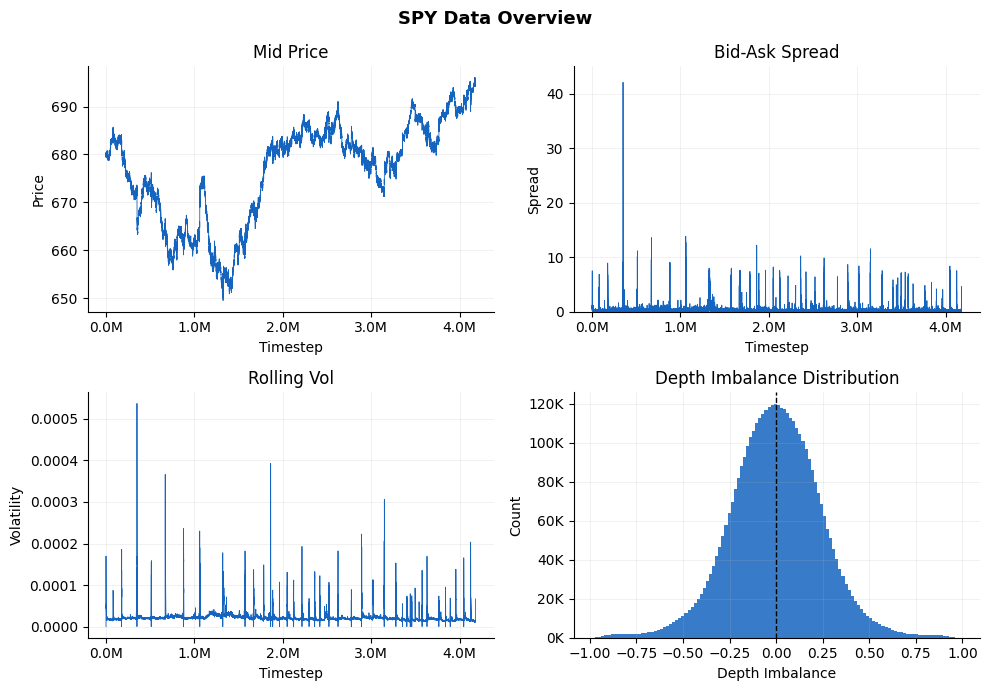

In [69]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("SPY Data Overview", fontsize=13, fontweight="bold")

# Subsample for plotting speed (every 10th point is plenty for a figure)
idx = np.arange(len(dfTrain))
step = 10

# Mid Price
axes[0, 0].plot(idx[::step], dfTrain["mid_price"].to_numpy()[::step], linewidth=0.6, color="#1565C0")
axes[0, 0].set_title("Mid Price")
axes[0, 0].set_xlabel("Timestep")
axes[0, 0].set_ylabel("Price")
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Spread (bps)
axes[0, 1].plot(idx[::step], dfTrain["spread_bps"].to_numpy()[::step], linewidth=0.6, color="#1565C0")
axes[0, 1].set_title("Bid-Ask Spread")
axes[0, 1].set_xlabel("Timestep")
axes[0, 1].set_ylabel("Spread")
axes[0, 1].set_ylim(0, 45)   # clip extreme spikes so the typical regime is visible
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Rolling Volatility
axes[1, 0].plot(idx[::step], dfTrain["vol_500tick"].to_numpy()[::step], linewidth=0.6, color="#1565C0")
axes[1, 0].set_title("Rolling Vol")
axes[1, 0].set_xlabel("Timestep")
axes[1, 0].set_ylabel("Volatility")
axes[1, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Depth Imbalance Distribution
axes[1, 1].hist(dfTrain["depth_imbalance_5"].to_numpy(), bins=120, color="#1565C0", edgecolor="none", alpha=0.85)
axes[1, 1].axvline(x=0, color="black", linestyle="--", linewidth=1.0)
axes[1, 1].set_title("Depth Imbalance Distribution")
axes[1, 1].set_xlabel("Depth Imbalance")
axes[1, 1].set_ylabel("Count")
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25, linewidth=0.5)

plt.tight_layout()
fig.set_size_inches(10, 7)
plt.savefig("data_overview.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

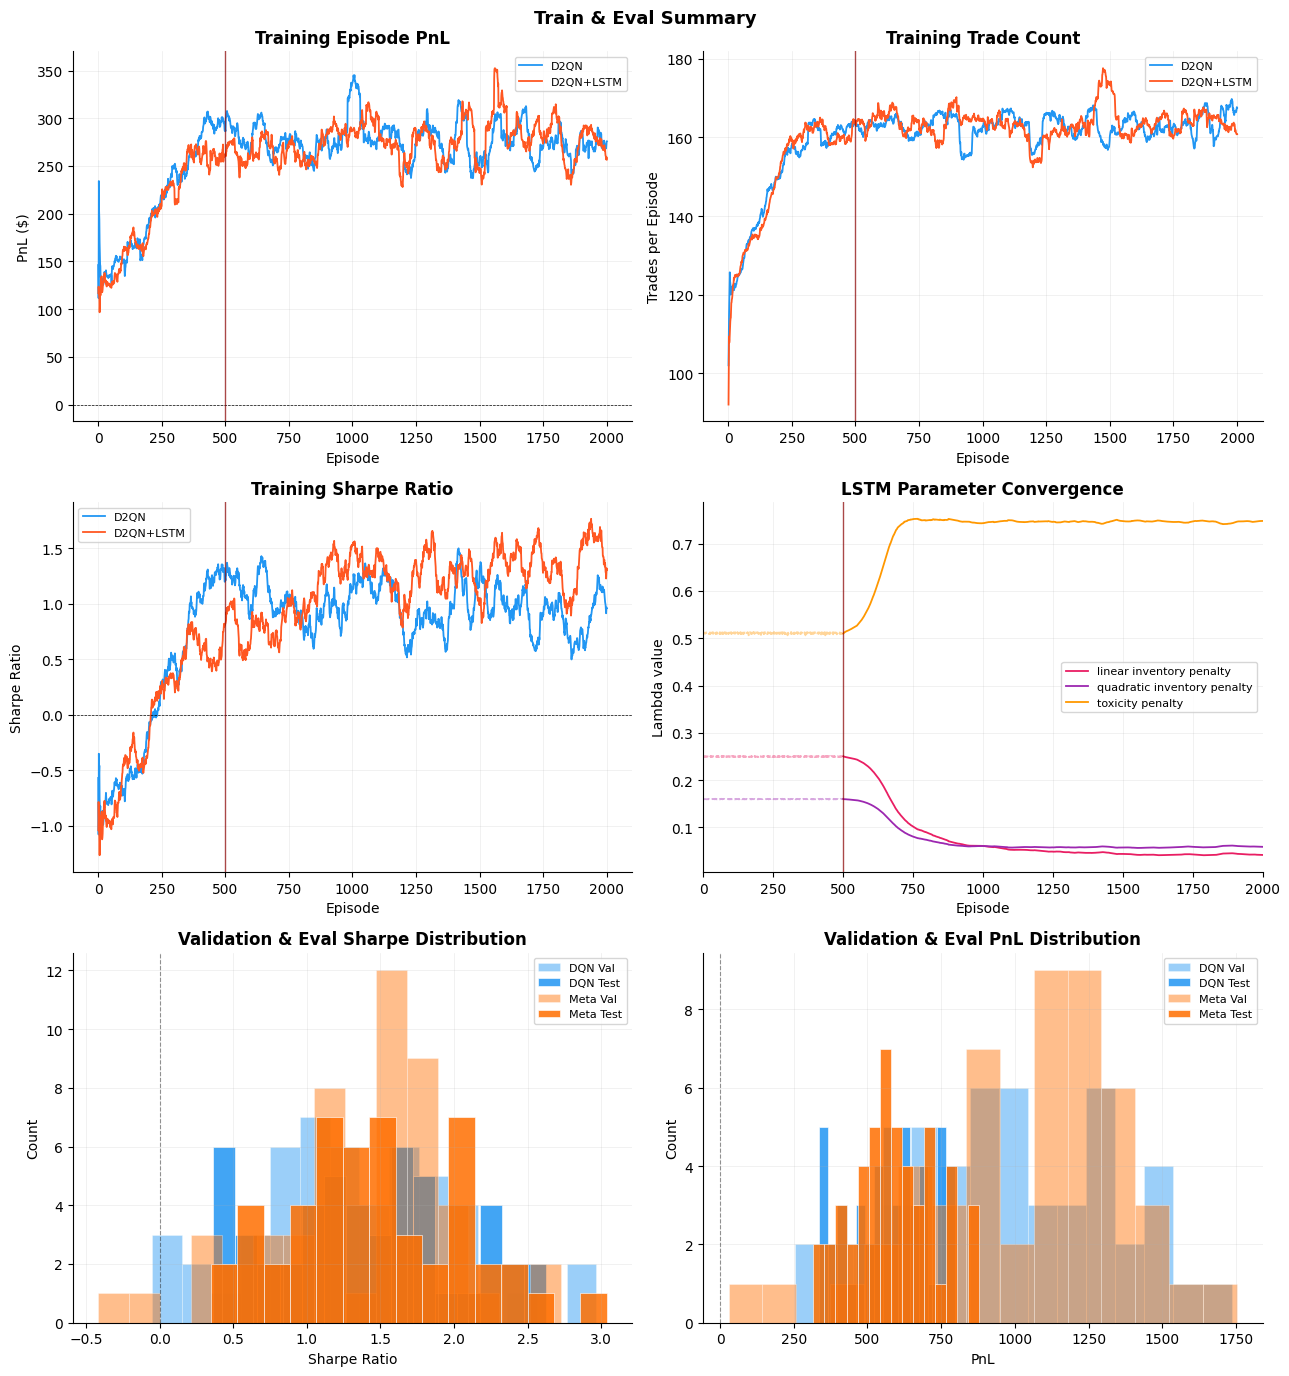

In [120]:
import matplotlib.pyplot as plt
import numpy as np

# ── Build dataframes and fix Meta episode indices ─────────────────────────
dqnDf  = pd.DataFrame(dqnTrainLog)
metaDf = pd.DataFrame(metaTrainLog)

active_mask = metaDf["phase"] == "active"
metaDf.loc[active_mask, "ep"] = range(501, 501 + active_mask.sum())

window = 50
dqn_r  = {col: dqnDf[col].rolling(window, min_periods=1).mean() for col in ["pnl", "sharpe", "trades"]}
meta_r = {col: metaDf[col].rolling(window, min_periods=1).mean() for col in ["pnl", "sharpe", "trades"]}

rl_datasets = {
    "DQN Val":  dqnVal,  "DQN Test":  dqnTest,
    "Meta Val": metaVal, "Meta Test": metaTest,
}
hist_colors = {"DQN Val": "#2196F3", "DQN Test": "#2196F3",
               "Meta Val": "#FF6F00", "Meta Test": "#FF6F00"}
hist_alphas = {"DQN Val": 0.45, "DQN Test": 0.85,
               "Meta Val": 0.45, "Meta Test": 0.85}

def style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25, linewidth=0.5)

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 14))
fig.suptitle("Train & Eval Summary", fontsize=13, fontweight="bold")

# ── Row 0: Training PnL | Training Trades ────────────────────────────────
axes[0, 0].plot(dqnDf["ep"],  dqn_r["pnl"],  color="#2196F3", linewidth=1.3, label="D2QN")
axes[0, 0].plot(metaDf["ep"], meta_r["pnl"],  color="#FF5722", linewidth=1.3, label="D2QN+LSTM")
axes[0, 0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0, 0].axvline(500, color="darkred", linewidth=1.0, alpha=0.7)
axes[0, 0].set_title("Training Episode PnL", fontweight="bold")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("PnL ($)")
axes[0, 0].legend(fontsize=8)
style(axes[0, 0])

axes[0, 1].plot(dqnDf["ep"],  dqn_r["trades"],  color="#2196F3", linewidth=1.3, label="D2QN")
axes[0, 1].plot(metaDf["ep"], meta_r["trades"],  color="#FF5722", linewidth=1.3, label="D2QN+LSTM")
axes[0, 1].axvline(500, color="darkred", linewidth=1.0, alpha=0.7)
axes[0, 1].set_title("Training Trade Count", fontweight="bold")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylabel("Trades per Episode")
axes[0, 1].legend(fontsize=8)
style(axes[0, 1])

# ── Row 1: Training Sharpe | Eval PnL ────────────────────────────────────
axes[1, 0].plot(dqnDf["ep"],  dqn_r["sharpe"],  color="#2196F3", linewidth=1.3, label="D2QN")
axes[1, 0].plot(metaDf["ep"], meta_r["sharpe"],  color="#FF5722", linewidth=1.3, label="D2QN+LSTM")
axes[1, 0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1, 0].axvline(500, color="darkred", linewidth=1.0, alpha=0.7)
axes[1, 0].set_title("Training Sharpe Ratio", fontweight="bold")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("Sharpe Ratio")
axes[1, 0].legend(fontsize=8)
style(axes[1, 0])

for name, data in rl_datasets.items():
    axes[2, 1].hist([d["pnl"] for d in data], bins=15, color=hist_colors[name],
                    alpha=hist_alphas[name], label=name, edgecolor="white", linewidth=0.5)
axes[2, 1].axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
axes[2, 1].set_title("Validation & Eval PnL Distribution", fontweight="bold")
axes[2, 1].set_xlabel("PnL")
axes[2, 1].set_ylabel("Count")
axes[2, 1].legend(fontsize=8)
style(axes[2, 1])

# ── Row 2: Eval Sharpe | Lambda Convergence ───────────────────────────────
for name, data in rl_datasets.items():
    axes[2, 0].hist([d["sharpe"] for d in data], bins=15, color=hist_colors[name],
                    alpha=hist_alphas[name], label=name, edgecolor="white", linewidth=0.5)
axes[2, 0].axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
axes[2, 0].set_title("Validation & Eval Sharpe Distribution", fontweight="bold")
axes[2, 0].set_xlabel("Sharpe Ratio")
axes[2, 0].set_ylabel("Count")
axes[2, 0].legend(fontsize=8)
style(axes[2, 0])

warmup = metaDf[metaDf["phase"] == "warmup"]
active = metaDf[metaDf["phase"] == "active"]
for col, color, label in [("lam0", "#E91E63", "linear inventory penalty"),
                           ("lam1", "#9C27B0", "quadratic inventory penalty"),
                           ("lam2", "#FF9800", "toxicity penalty")]:
    axes[1, 1].plot(warmup["ep"], warmup[col],
                    color=color, linewidth=1.3, linestyle="--", alpha=0.4)
    axes[1, 1].plot(active["ep"], active[col].rolling(window, min_periods=1).mean(),
                    color=color, linewidth=1.3, label=label)
axes[1, 1].axvline(500, color="darkred", linewidth=1.0, alpha=0.7)
axes[1, 1].set_xlim(0, metaDf["ep"].max())
axes[1, 1].set_title("LSTM Parameter Convergence", fontweight="bold")
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylabel("Lambda value")
axes[1, 1].legend(fontsize=8)
style(axes[1, 1])

plt.tight_layout()
plt.savefig("combined_results.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()